In [1]:
# Import necessary libraries and modules
import numpy as np 
import pandas as pd 
import os 
import itertools
from PIL import Image 
import matplotlib.pyplot as plt 
import seaborn as sns
sns.set_style('darkgrid') 
import json
from sklearn.model_selection import train_test_split 
from sklearn.metrics import confusion_matrix , classification_report
 
import tensorflow as tf
from tensorflow.keras.callbacks import Callback, EarlyStopping,ModelCheckpoint, ReduceLROnPlateau
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import GlobalAveragePooling2D,Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization,Concatenate
from tensorflow.keras import layers
from tensorflow.keras.regularizers import l2
from sklearn.metrics import precision_score, recall_score, f1_score,accuracy_score 
import warnings
warnings.filterwarnings("ignore")  
import gc


I0000 00:00:1776103413.629114   45404 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776103414.004125   45404 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776103415.696747   45404 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
import tensorflow as tf
tf.get_logger().setLevel('ERROR')
print("LD_LIBRARY_PATH:", os.environ.get('LD_LIBRARY_PATH', 'NOT SET'))
print()
print("WSL lib contents:")
print(os.listdir('/usr/lib/wsl/lib'))

import ctypes

# Force load cudart before tensorflow
cudart_path = '/usr/local/cuda-12.5/lib64/libcudart.so.12'
ctypes.CDLL(cudart_path)

import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

LD_LIBRARY_PATH: /usr/local/cuda-12.5/lib64:/usr/lib/wsl/lib:/usr/lib/wsl/lib::/lib

WSL lib contents:
['libcuda.so', 'libcuda.so.1', 'libcuda.so.1.1', 'libcudadebugger.so.1', 'libnvcuvid.so', 'libnvcuvid.so.1', 'libnvdxdlkernels.so', 'libnvidia-encode.so', 'libnvidia-encode.so.1', 'libnvidia-gpucomp.so', 'libnvidia-ml.so.1', 'libnvidia-ngx.so.1', 'libnvidia-opticalflow.so', 'libnvidia-opticalflow.so.1', 'libnvoptix.so.1', 'libnvwgf2umx.so', 'nvidia-ngx-updater', 'nvidia-smi', 'libnvidia-gpucomp.so.595.58.02', 'libnvoptix_loader.so.1', 'libd3d12.so', 'libd3d12core.so', 'libdxcore.so']
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
#load dataset
img_size = (224, 224)   
batch_size = 8
 
tr_gen = ImageDataGenerator(rescale=1.0/255.0,  
                            horizontal_flip=True,   
                           ) 

tst_gen = ImageDataGenerator(rescale=1.0/255.0);
 
train_gen = tr_gen.flow_from_directory('data/train',   
                                       target_size=img_size, 
                                       class_mode='categorical', 
                                       color_mode='rgb', 
                                       shuffle=True, 
                                       batch_size=batch_size 
                                      )  
 
val_gen = tr_gen.flow_from_directory('data/validation',  
                                       target_size=img_size, 
                                       class_mode='categorical', 
                                       color_mode='rgb', 
                                       shuffle=False, 
                                       batch_size=batch_size 
                                      )  
 
test_gen = tst_gen.flow_from_directory('data/test',   
                                      target_size=img_size, 
                                      class_mode='categorical', 
                                      color_mode='rgb', 
                                      shuffle=False, 
                                      batch_size=batch_size
                                     )



Found 2191 images belonging to 2 classes.
Found 547 images belonging to 2 classes.
Found 687 images belonging to 2 classes.


In [4]:
#define attention block function

from tensorflow.keras.layers import (
    Layer, Conv2D, Dense, GlobalAveragePooling2D, Multiply, 
    Add, Softmax, Reshape
)

class AttentionBlock(Layer): 
    def __init__(self, attention_type="cbam", reduction_ratio=16, **kwargs):
        super(AttentionBlock, self).__init__(**kwargs) 
        self.attention_type = attention_type.lower()
        self.reduction_ratio = reduction_ratio

    def build(self, input_shape):
        filters = input_shape[-1]
        reduced_filters = max(filters // self.reduction_ratio, 1)
 
        if self.attention_type == "se":
            self.global_avg_pool = GlobalAveragePooling2D()
            self.dense1 = Dense(reduced_filters, activation="relu")
            self.dense2 = Dense(filters, activation="sigmoid")
 
        elif self.attention_type == "self":
            self.query_conv = Conv2D(filters // 8, (1, 1), padding="same")
            self.key_conv = Conv2D(filters // 8, (1, 1), padding="same")
            self.value_conv = Conv2D(filters, (1, 1), padding="same")
 
        elif self.attention_type == "cbam":
            self.global_avg_pool = GlobalAveragePooling2D()
            self.dense1 = Dense(reduced_filters, activation="relu")
            self.dense2 = Dense(filters, activation="sigmoid") 
            self.spatial_attention = Conv2D(1, (7, 7), activation="sigmoid", padding="same")

    def call(self, inputs): 
        if self.attention_type == "se": 
            se = self.global_avg_pool(inputs)
            se = self.dense1(se)
            se = self.dense2(se)
            se = Reshape((1, 1, -1))(se)
            return Multiply()([inputs, se])
 
        elif self.attention_type == "self": 
            query = self.query_conv(inputs)
            key = self.key_conv(inputs)
            value = self.value_conv(inputs)  
            attention = Softmax(axis=-1)(tf.linalg.matmul(query, key, transpose_b=True)) 
            attention = tf.linalg.matmul(attention, value) 
            return Add()([inputs, attention])
 
        elif self.attention_type == "cbam":
            # CBAM - Önce Kanal Dikkati
            ca = self.global_avg_pool(inputs)
            ca = self.dense1(ca)
            ca = self.dense2(ca)
            ca = Reshape((1, 1, -1))(ca)
            x = Multiply()([inputs, ca]) 
            sa = self.spatial_attention(x)
            x = Multiply()([x, sa]) 
            return x
  

def build_model(model_name='resnet18' ):
# Load DenseNet201 model pre-trained on ImageNet without top layers
    base_model = tf.keras.applications.DenseNet201(include_top=False, weights='imagenet', input_shape=(224, 224, 3),pooling= None) 
    
    x = base_model.get_layer("pool3_relu").output
# Apply self-attention mechanism to enhance feature representations
    x = AttentionBlock(attention_type="self")(x) 
    x = base_model.get_layer("conv5_block32_concat").output  
     
    x = GlobalAveragePooling2D()(x)
    x = Dense(1024, activation='relu',kernel_regularizer=l2(0.01))(x)
    x = Dropout(0.5)(x)
    x = BatchNormalization()(x)
    x = Dense(128, activation='relu')(x)
    x = Dense(2, activation='softmax')(x)   
     
# Define the final model architecture and connect input-output layers
    model = tf.keras.Model(inputs=base_model.input, outputs=x)

    return model

In [6]:
from tensorflow.keras.layers import Multiply 
import numpy as np 
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
 
model = build_model()
# Compile the model with optimizer, loss function, and metrics
model.compile(
    optimizer=Adam(0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.1, 
    patience=3, 
    min_lr=1e-6,
    verbose=1
)
model.summary()
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True,
    verbose=1
)
#Train the model with training and validation datasets
history = model.fit(
    train_gen,
    epochs=50, 
    validation_data=val_gen,
    verbose=1,
    callbacks=[early_stopping,reduce_lr]
)

# Evaluate the model performance on test dataset
results = model.evaluate(test_gen,verbose=0)
print(f'Test Loss: {results[0]}, Test Accuracy: {results[1]}\n')
y_true = test_gen.classes   
# Generate predictions using the trained model
y_pred_probs = model.predict(test_gen, verbose=1)  
y_pred = np.argmax(y_pred_probs, axis=1)   
y_true = np.array(y_true)
y_pred = np.array(y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted') 
# Compute the confusion matrix to analyze classification performance
cm = confusion_matrix(y_true, y_pred)
if cm.shape == (2,2):   
    TN, FP, FN, TP = cm.ravel()
    specificity = TN / (TN + FP)
else:
    specificity = None  
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
if specificity is not None:
    print(f"Specificity: {specificity:.4f}")
print(f"F1 Score: {f1:.4f}")
    

I0000 00:00:1776103444.778485   45404 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3536 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 532s 7us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 20,416,962 (77.88 MB)

...

Epoch 1/50


I0000 00:00:1776103984.409600   45404 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1776104034.792503   45639 service.cc:153] XLA service 0x73164004cb70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776104034.792561   45639 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9 (Driver: 13.2.0; Runtime: 12.5.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1776104036.828652   45639 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776104047.602567   45639 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1776104050.711118   45639 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_133580__.1248
I0000 00:00:1776104153.968421   47620 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_reduce

231/274 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step - accuracy: 0.5623 - loss: 11.9373

I0000 00:00:1776104622.435866   45636 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_133580__.1248
I0000 00:00:1776104714.946161   58329 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_compare_reduce_fusion_20', 64 bytes spill stores, 8 bytes spill loads

I0000 00:00:1776104716.761760   58329 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion_22', 232 bytes spill stores, 8 bytes spill loads

I0000 00:00:1776104727.772144   58318 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion_21', 224 bytes spill stores, 8 bytes spill loads

I0000 00:00:1776104729.930854   58318 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_compare_reduce_fusion_25', 80 bytes spill stores, 8 bytes spill loads

I0000 00:00:1776104

274/274 ━━━━━━━━━━━━━━━━━━━━ 1001s 1s/step - accuracy: 0.6148 - loss: 9.5452 - val_accuracy: 0.7605 - val_loss: 6.1520 - learning_rate: 1.0000e-04
Epoch 2/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 29s 104ms/step - accuracy: 0.7974 - loss: 4.3997 - val_accuracy: 0.8080 - val_loss: 3.1538 - learning_rate: 1.0000e-04
Epoch 3/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 31s 114ms/step - accuracy: 0.8444 - loss: 2.3858 - val_accuracy: 0.8885 - val_loss: 1.7805 - learning_rate: 1.0000e-04
Epoch 4/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 30s 110ms/step - accuracy: 0.8731 - loss: 1.4553 - val_accuracy: 0.8154 - val_loss: 1.3104 - learning_rate: 1.0000e-04
Epoch 5/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 30s 110ms/step - accuracy: 0.8964 - loss: 0.9247 - val_accuracy: 0.8684 - val_loss: 0.9303 - learning_rate: 1.0000e-04
Epoch 6/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 30s 110ms/step - accuracy: 0.9078 - loss: 0.6381 - val_accuracy: 0.8940 - val_loss: 0.5923 - learning_rate: 1.0000e-04
Epoch 7/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 30s 110ms/step - a

In [7]:
#save history
hist_df = pd.DataFrame(history.history)
hist_df.to_csv('history.csv', index=False)

In [11]:
def plot_history(history, model_name, best): 
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    learning_rate = history.history['learning_rate']
    epochs = np.arange(1, len(loss) + 1)
 
# Visualize training performance metrics such as accuracy and loss
    fig, ax1 = plt.subplots(figsize=(9, 5))
 
    ax1.plot(epochs, loss, label='Train Loss', color="#1f77b4", linewidth=2.5, linestyle='-', alpha=0.8)
    ax1.plot(epochs, val_loss, label='Validation Loss', color="#ff7f0e", linewidth=2.5, linestyle='-', alpha=0.8)
 
    ax1.scatter(best, val_loss[best-1], color='red', s=100, edgecolors='black', zorder=3, label='Best Validation Loss')
 
    ax1.set_yscale('log')
    ax1.set_xlabel('Epochs', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Loss (Log Scale)', fontsize=12, fontweight='bold')
    ax1.set_title(f'{model_name} Training Progress', fontsize=14, fontweight='bold')
 
    ax1.grid(which='both', linestyle=':', linewidth=0.7, alpha=0.6)
    ax1.set_facecolor('#f7f7f7')
 
    ax2 = ax1.twinx()
    ax2.plot(epochs, learning_rate, color='green', linestyle='dotted', linewidth=2, alpha=0.7, label="Learning Rate")
    ax2.set_ylabel('Learning Rate', fontsize=12, fontweight='bold')
    ax2.tick_params(axis='y', labelcolor='green')
 
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right', fontsize=10, frameon=True, facecolor="white")
 
    ax1.axvline(x=best, color='red', linestyle='--', linewidth=1.5, alpha=0.8)
 
# Visualize training performance metrics such as accuracy and loss
    plt.savefig(f"{model_name}_training_plot.png", dpi=300, bbox_inches='tight', facecolor='white')
 
    plt.show()


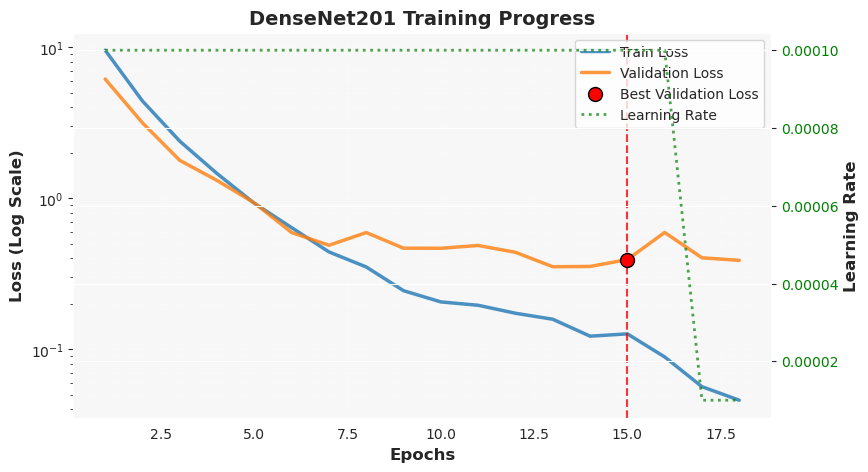

In [12]:
#create training graph
plot_history(history,'DenseNet201',15)

In [13]:
# Import necessary libraries and modules
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.metrics import confusion_matrix
 

def create_cf_matrix(model, model_name, fontsize=14): 
# Generate predictions using the trained model
    y_pred_probs = model.predict(test_gen, verbose=1)
    y_pred_classes = np.argmax(y_pred_probs, axis=1)
 
    y_true = test_gen.classes
 
# Compute the confusion matrix to analyze classification performance
    conf_matrix = confusion_matrix(y_true, y_pred_classes)
 
    class_names = ['Normal', 'SL']
 
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix,
                annot=True,
                fmt='d',
                cmap='Blues',
                annot_kws={"size": fontsize},
                xticklabels=class_names,
                yticklabels=class_names)

    plt.ylabel('Actual', fontsize=fontsize + 2)
    plt.xlabel('Predicted', fontsize=fontsize + 2) 
    plt.xticks(fontsize=fontsize)
    plt.yticks(fontsize=fontsize)

    plt.title(f'Confusion Matrix - {model_name}', fontsize=fontsize + 4)
    plt.tight_layout()
# Save the trained model or results for later use
    plt.savefig(f'{model_name}.jpg', dpi=300)
    plt.show()



86/86 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step


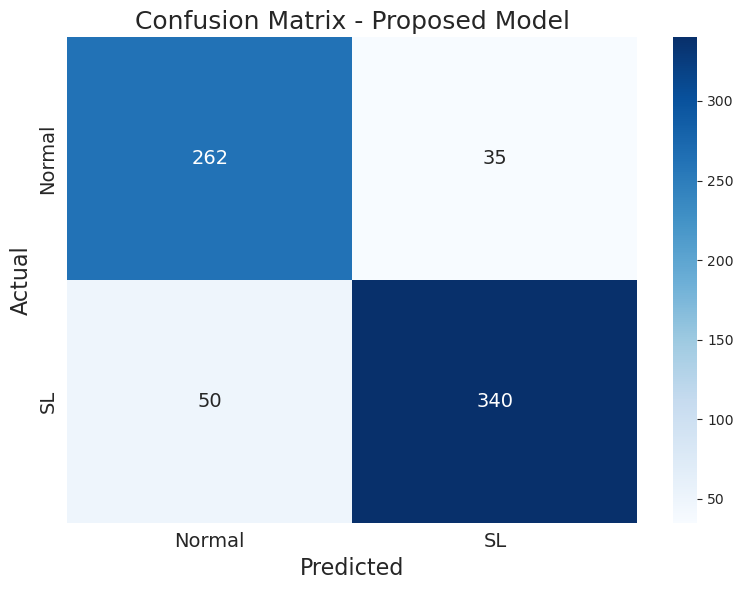

In [14]:
#create confusion matrix
create_cf_matrix(model,'Proposed Model')